In [ ]:
from google.colab import files
uploaded = files.upload()

Saving starry_night.jpg to starry_night (1).jpg


Step 0:
Style Loss : 0.035598 Content Loss: 0.000000
Step 50:
Style Loss : 0.006442 Content Loss: 11.947006
Step 100:
Style Loss : 0.004848 Content Loss: 11.869995
Step 150:
Style Loss : 0.018926 Content Loss: 30.061722
Step 200:
Style Loss : 0.174875 Content Loss: 59.075035
Step 250:
Style Loss : 0.003366 Content Loss: 14.314422
Step 300:
Style Loss : 0.018721 Content Loss: 29.622841


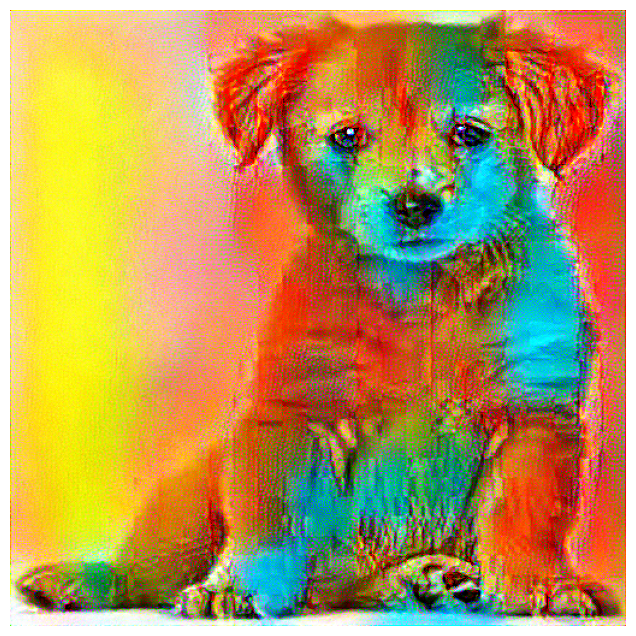

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------
# 1️⃣ Image Loader
# --------------------------------------------
def load_image(path, size=512):
    image = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

# --------------------------------------------
# 2️⃣ Normalization for VGG
# --------------------------------------------
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = torch.tensor(mean).view(-1,1,1).to(device)
        self.std = torch.tensor(std).view(-1,1,1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std

cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

for param in cnn.parameters():
    param.requires_grad = False

normalization_mean = [0.485, 0.456, 0.406]
normalization_std = [0.229, 0.224, 0.225]

normalization = Normalization(normalization_mean, normalization_std)

# --------------------------------------------
# 3️⃣ Content & Style Layers
# --------------------------------------------
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

# --------------------------------------------
# 4️⃣ Gram Matrix
# --------------------------------------------
def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(c, h * w)
    G = torch.mm(features, features.t())
    return G.div(c * h * w)

# --------------------------------------------
# 5️⃣ Build Model with Loss
# --------------------------------------------
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

def get_model_and_losses(cnn, normalization, content_img, style_img):
    cnn = copy.deepcopy(cnn)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            name = f'layer_{i}'

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    return model, style_losses, content_losses

model, style_losses, content_losses = get_model_and_losses(
    cnn, normalization, content_img, style_img
)

# --------------------------------------------
# 6️⃣ Optimize Image
# --------------------------------------------
input_img = content_img.clone()
optimizer = optim.LBFGS([input_img.requires_grad_()])

style_weight = 3e4
content_weight = 25

num_steps = 300
run = [0]

while run[0] <= num_steps:

    def closure():
        input_img.data.clamp_(0, 1)

        optimizer.zero_grad()
        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        loss = style_weight * style_score + content_weight * content_score
        loss.backward()

        if run[0] % 50 == 0:
            print(f"Step {run[0]}:")
            print(f"Style Loss : {style_score.item():4f} "
                  f"Content Loss: {content_score.item():4f}")

        run[0] += 1
        return loss

    optimizer.step(closure)

input_img.data.clamp_(0, 1)import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------
# 1️⃣ Image Loader
# --------------------------------------------
def load_image(path, size=512):
    image = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

# --------------------------------------------
# 2️⃣ Normalization for VGG
# --------------------------------------------
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = torch.tensor(mean).view(-1,1,1).to(device)
        self.std = torch.tensor(std).view(-1,1,1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std

cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

for param in cnn.parameters():
    param.requires_grad = False

normalization_mean = [0.485, 0.456, 0.406]
normalization_std = [0.229, 0.224, 0.225]

normalization = Normalization(normalization_mean, normalization_std)

# --------------------------------------------
# 3️⃣ Content & Style Layers
# --------------------------------------------
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

# --------------------------------------------
# 4️⃣ Gram Matrix
# --------------------------------------------
def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(c, h * w)
    G = torch.mm(features, features.t())
    return G.div(c * h * w)

# --------------------------------------------
# 5️⃣ Build Model with Loss
# --------------------------------------------
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

def get_model_and_losses(cnn, normalization, content_img, style_img):
    cnn = copy.deepcopy(cnn)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            name = f'layer_{i}'

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    return model, style_losses, content_losses

model, style_losses, content_losses = get_model_and_losses(
    cnn, normalization, content_img, style_img
)

# --------------------------------------------
# 6️⃣ Optimize Image
# --------------------------------------------
input_img = content_img.clone()
optimizer = optim.LBFGS([input_img.requires_grad_()])

style_weight = 3e4
content_weight = 25

num_steps = 300
run = [0]

while run[0] <= num_steps:

    def closure():
        input_img.data.clamp_(0, 1)

        optimizer.zero_grad()
        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        loss = style_weight * style_score + content_weight * content_score
        loss.backward()

        if run[0] % 50 == 0:
            print(f"Step {run[0]}:")
            print(f"Style Loss : {style_score.item():4f} "
                  f"Content Loss: {content_score.item():4f}")

        run[0] += 1
        return loss

    optimizer.step(closure)

input_img.data.clamp_(0, 1)

# --------------------------------------------
# 7️⃣ Show Final Image
# --------------------------------------------
def imshow(tensor):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.figure(figsize=(8,8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(input_img)

# --------------------------------------------
# 7️⃣ Show Final Image
# --------------------------------------------
def imshow(tensor):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.figure(figsize=(8,8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(input_img)

Step 0:
Style Loss : 0.035598 Content Loss: 0.000000
Step 50:
Style Loss : 0.005289 Content Loss: 13.819547
Step 100:
Style Loss : 0.003084 Content Loss: 14.424340
Step 150:
Style Loss : 0.002906 Content Loss: 13.857036
Step 200:
Style Loss : 0.002877 Content Loss: 14.560751
Step 250:
Style Loss : 0.004370 Content Loss: 19.256069
Step 300:
Style Loss : 0.004098 Content Loss: 17.976059


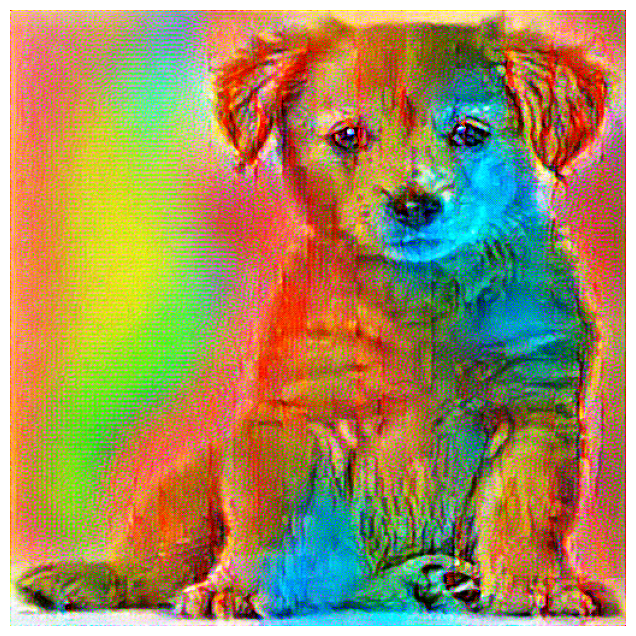

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------
# 1️⃣ Image Loader
# --------------------------------------------
def load_image(path, size=512):
    image = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

# --------------------------------------------
# 2️⃣ Normalization for VGG
# --------------------------------------------
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = torch.tensor(mean).view(-1,1,1).to(device)
        self.std = torch.tensor(std).view(-1,1,1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std

cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

for param in cnn.parameters():
    param.requires_grad = False

normalization_mean = [0.485, 0.456, 0.406]
normalization_std = [0.229, 0.224, 0.225]

normalization = Normalization(normalization_mean, normalization_std)

# --------------------------------------------
# 3️⃣ Content & Style Layers
# --------------------------------------------
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

# --------------------------------------------
# 4️⃣ Gram Matrix
# --------------------------------------------
def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(c, h * w)
    G = torch.mm(features, features.t())
    return G.div(c * h * w)

# --------------------------------------------
# 5️⃣ Build Model with Loss
# --------------------------------------------
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

def get_model_and_losses(cnn, normalization, content_img, style_img):
    cnn = copy.deepcopy(cnn)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            name = f'layer_{i}'

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    return model, style_losses, content_losses

model, style_losses, content_losses = get_model_and_losses(
    cnn, normalization, content_img, style_img
)

# --------------------------------------------
# 6️⃣ Optimize Image
# --------------------------------------------
input_img = content_img.clone()
optimizer = optim.LBFGS([input_img.requires_grad_()])

style_weight = 3e4
content_weight = 20

num_steps = 300
run = [0]

while run[0] <= num_steps:

    def closure():
        input_img.data.clamp_(0, 1)

        optimizer.zero_grad()
        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        loss = style_weight * style_score + content_weight * content_score
        loss.backward()

        if run[0] % 50 == 0:
            print(f"Step {run[0]}:")
            print(f"Style Loss : {style_score.item():4f} "
                  f"Content Loss: {content_score.item():4f}")

        run[0] += 1
        return loss

    optimizer.step(closure)

input_img.data.clamp_(0, 1)

# --------------------------------------------
# 7️⃣ Show Final Image
# --------------------------------------------
def imshow(tensor):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.figure(figsize=(8,8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(input_img)